<h1 align="center"> Inference </h1>

Finds ultrasound image and RNA-seq embeddings, and diagnosis. Final datasets exported to master DataFrames.

<br>
<i> Import necessary libraries: <i>

In [1]:
# Additional imports needed to load src.model and src.dataset
import sys
sys.path.append("..")

import os
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
import torch
import pandas as pd
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader
from src.model import CLIPModel, RNAEncoder, ImageEncoder, ContrastiveLoss
from src.dataset import RNACustomDataset, ImgCustomDataset
from sklearn.model_selection import train_test_split
import torch.nn as nn 
import numpy as np
import albumentations as albu # For image augmentations
import cv2
from albumentations.pytorch import ToTensorV2
from src.optimise import set_seed, calc_mean_std, generate_model_name, capitalize_j, format_case_id
from sklearn.preprocessing import StandardScaler
from sklearn import preprocessing

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from scipy.stats import spearmanr
np.random.seed(2)

# Set random seed for weights
random_seed = 2
set_seed(random_seed)

from sklearn.manifold import TSNE
import time

Random seed set as 2


### Load Data

In [2]:
# Step 1: Load RNA-Seq data
df_rna = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/rna_counts/RNA_counts_141024.csv", header=None, low_memory=False)
df_rna_transposed = df_rna.transpose()
new_header = df_rna_transposed.iloc[1]
df_rna_transposed = df_rna_transposed[2:]
df_rna_transposed.columns = new_header
df_rna_transposed.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces

# Step 3: Filter RNA data for 'ENSG' columns
rna_cols = df_rna_transposed.filter(like='ENSG')

# Step 4: Load and merge image data
df_images = pd.read_excel("/home/kryan24/MRes_Ultrasound/data/metadata/RNA_Sample_Linking2.xlsx")
df_images.rename(columns=lambda x: x.strip(), inplace=True) # Trim whitespaces
df_images['Sample ID'] = df_images['Sample ID'].str.replace(' ', '_')
df_images["SURGICAL"] = df_images["SURGICAL"].str.strip() # Remove whitespaces from SURGICAL

df_merged = pd.merge(df_images, df_rna_transposed, left_on="Sample ID", right_on="Geneid")

df_merged_copy = df_merged

# Step 5: Correct data quality issues
df_merged["Extraction site"] = df_merged["Extraction site"].str.strip()
df_merged["Extraction site"] = df_merged["Extraction site"].str.lower()

# Step 6: Read the CSV file into a DataFrame 
df_radiomics = pd.read_csv("/home/kryan24/MRes_Ultrasound/data/metadata/radiomics_clinical_Barcroft_12_01_23.csv", low_memory=False)
# Remove first 2 columns
df_radiomics.drop(df_radiomics.columns[[0, 1]], axis=1, inplace=True)

# Filter columns
df_radiomics = df_radiomics.drop(df_radiomics.iloc[:, 3907:3950], axis=1)
df_radiomics["MAHCINE_CORECCTED"] = df_radiomics["MAHCINE_CORECCTED"].str.strip() # Remove whitespaces from MAHCINE_CORECCTED

# Step 7: Match radiomics data to metadata and filter DataFrame
df_radiomics_meta = df_merged[["Extraction site", "SURGICAL", "CASE ID", "CASE ID2"]]

# Step 8: Merge DataFrames
df_merged2 = pd.merge(df_radiomics_meta, df_radiomics, left_on="CASE ID", right_on="ID")

# Step 9: Correct data quality issues
df_merged2 = df_merged2.drop(["ID"], axis=1)

# Step 10: Keep the same samples for RNA as radiomics data
case_id_list = df_merged2["CASE ID"].tolist()
mask = df_merged["CASE ID"].isin(case_id_list)
df_merged = df_merged[mask]

### Pair Images and RNA Data

In [3]:
# Step 1: Prepare image filenames and filter RNA data
image_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/images_matched"
image_filenames = []
rna_data_filtered = []
surgical = []
sample_count = 0 

paired_id_list = []

In [4]:
for index, row in df_merged.iterrows():

    # Format and capitalize the CASE IDs
    case_id = capitalize_j(format_case_id(row['CASE ID']))
    case_id2 = capitalize_j(format_case_id(row['CASE ID2']))

    for file_name in os.listdir(image_directory):
        if file_name.endswith('.nii.gz') and 'seg' not in file_name:
            file_name_corrected = capitalize_j(file_name)  # Capitalize 'j' in the filename

            # Check if either case_id or case_id2 is a substring of the filename
            # Only check if the ID is non-empty
            if (case_id and case_id in file_name_corrected):
                image_filenames.append(file_name)
                rna_data_filtered.append(
                    row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                surgical.append(row["SURGICAL"])
                paired_id_list.append(case_id)
                sample_count += 1
                break

            if (case_id2 and case_id2 in file_name_corrected):
                image_filenames.append(file_name)
                rna_data_filtered.append(
                    row[rna_cols.columns].apply(pd.to_numeric, errors='coerce').fillna(0)
                    )
                surgical.append(row["SURGICAL"])
                paired_id_list.append(case_id2)
                sample_count += 1
                break

print(f"Number of Samples: ", sample_count)

Number of Samples:  29


In [5]:
# Create DataFrame for surgical matching
match_dict = {"image_name": image_filenames, "ID": paired_id_list, "SURGICAL": surgical} 
match_df = pd.DataFrame(match_dict)
match_df

,image_name,ID,SURGICAL
0,12930_3.nii.gz,12930,B-S
1,13291_0010.nii.gz,13291,M-S
2,14023_3.nii.gz,14023,M-S
3,14056_3.nii.gz,14056,M-S
4,14654_3.nii.gz,14654,M-S
5,14024_2.nii.gz,14024,M-S
6,14984_0039.nii.gz,14984,M-S
7,16106_0022.nii.gz,16106,B-S
8,16134_0049.nii.gz,16134,M-S
9,16208_1.nii.gz,16208,B-S


### Train-test Split

In [6]:
# Convert to DataFrame
rna_data_filtered = pd.DataFrame(rna_data_filtered)

In [7]:
# Step 1: Split into train and test sets
rna_train, rna_test, img_train, img_test, surg_train, surg_test = train_test_split(rna_data_filtered, image_filenames, surgical, test_size=0.2, random_state=2)

In [8]:
# Convert back to DataFrame
rna_train = pd.DataFrame(rna_train, columns=rna_data_filtered.columns)
rna_test = pd.DataFrame(rna_test, columns=rna_data_filtered.columns)

In [9]:
print(f"Number of RNA samples: ", rna_train.shape[0])
print(f"Number of image filenames: ", len(img_train))
print(f"Number of diagnoses: ", len(surg_train))
print(f"Image filenames: ", img_train)
print(f"Diagnoses: ", surg_train)

Number of RNA samples:  23
Number of image filenames:  23
Number of diagnoses:  23
Image filenames:  ['24903_0011.nii.gz', '14984_0039.nii.gz', '14056_3.nii.gz', '25962_0006.nii.gz', '26604_0007.nii.gz', '26428_0020.nii.gz', '187867.nii.gz', '14654_3.nii.gz', '16439_0004.nii.gz', '14024_2.nii.gz', '25970_2.nii.gz', '25607_0005.nii.gz', '14023_3.nii.gz', '16106_0022.nii.gz', '26425_-3.nii.gz', '26417_1.nii.gz', '25827_0006.nii.gz', '18638_0037.nii.gz', 'J630_0008.nii.gz', '26379_5.nii.gz', '18853_0020.nii.gz', '24354_0019.nii.gz', '16134_0049.nii.gz']
Diagnoses:  ['M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'B-S', 'B-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S', 'M-S']


In [10]:
print(f"Number of RNA samples: ", rna_test.shape[0])
print(f"Number of image filenames: ", len(img_test))
print(f"Number of diagnoses: ", len(surg_test))
print(f"Image filenames: ", img_test)
print(f"Diagnoses: ", surg_test)

Number of RNA samples:  6
Number of image filenames:  6
Number of diagnoses:  6
Image filenames:  ['13291_0010.nii.gz', '12930_3.nii.gz', '18852_0009.nii.gz', '16208_1.nii.gz', '25961_2.nii.gz', '26424_0007.nii.gz']
Diagnoses:  ['M-S', 'B-S', 'B-S', 'B-S', 'M-S', 'M-S']


## Scale and Transform the Data

In [11]:
# Scale RNA sample counts
scaler_rna_counts = StandardScaler()
rna_train = pd.DataFrame(scaler_rna_counts.fit_transform(rna_train), columns=rna_data_filtered.columns)

In [12]:
rna_train

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,0.391489,2.095373,0.845661,0.0,-0.706518,-0.213201,0.0,-0.273434,0.0,-0.277051,...,0.982061,-0.458831,-0.213201,-0.458831,-0.249747,-0.598463,-0.098433,0.593454,0.0,0.405475
1,-0.608984,3.877982,-0.323115,0.0,0.969914,-0.213201,0.0,-0.273434,0.0,0.411754,...,-0.462295,-0.458831,-0.213201,-0.458831,-0.608811,-1.222228,-1.356184,-0.633742,0.0,-0.799880
2,2.392435,-0.412902,-0.345168,0.0,-0.366051,4.690416,0.0,-0.273434,0.0,-1.291525,...,0.542950,2.179449,-0.213201,-0.458831,2.369211,1.905593,2.165519,0.649293,0.0,1.536534
3,1.391962,-0.570655,-0.179775,0.0,0.022526,-0.213201,0.0,-0.273434,0.0,0.429047,...,-0.439767,-0.458831,-0.213201,2.179449,-0.197033,-0.315460,0.153118,-0.379423,0.0,-0.643496
4,0.391489,-0.144721,2.499588,0.0,0.092840,-0.213201,0.0,1.298813,0.0,-0.297225,...,0.925221,-0.458831,-0.213201,-0.458831,-0.159288,0.478861,-0.098433,0.594507,0.0,0.026723
5,-0.608984,-0.539104,-1.117001,0.0,-1.117300,-0.213201,0.0,4.443309,0.0,-0.089719,...,0.503722,-0.458831,-0.213201,2.179449,-0.517806,-0.230226,-1.607734,0.483332,0.0,1.357289
6,1.892199,-0.428677,0.139985,0.0,0.126147,-0.213201,0.0,-0.273434,0.0,0.097613,...,-0.830967,2.179449,-0.213201,-0.458831,-0.740485,-0.584550,-0.601533,-0.532274,0.0,-0.567642
7,1.892199,-0.334025,-1.183158,0.0,-0.247627,-0.213201,0.0,-0.273434,0.0,-0.660361,...,-0.803359,2.179449,4.690416,2.179449,0.426300,0.350044,0.404668,-0.600500,0.0,0.462625
8,-0.608984,-0.255148,-0.764163,0.0,0.118745,-0.213201,0.0,-0.273434,0.0,1.048683,...,-0.076327,-0.458831,-0.213201,-0.458831,-0.470768,1.787090,1.913969,-0.312919,0.0,-0.664278
9,-0.608984,0.312763,0.128958,0.0,-1.628001,-0.213201,0.0,-0.273434,0.0,-0.611366,...,-0.540527,-0.458831,-0.213201,-0.458831,-0.622723,-0.222019,-0.349983,-0.449639,0.0,-0.869500


In [13]:
# Scale RNA sample counts
rna_test = pd.DataFrame(scaler_rna_counts.transform(rna_test), columns=rna_data_filtered.columns)

In [14]:
rna_test

1,ENSG00000279928,ENSG00000228037,ENSG00000142611,ENSG00000284616,ENSG00000157911,ENSG00000260972,ENSG00000224340,ENSG00000226374,ENSG00000229280,ENSG00000142655,...,ENSG00000198886,ENSG00000210176,ENSG00000210184,ENSG00000210191,ENSG00000198786,ENSG00000198695,ENSG00000210194,ENSG00000198727,ENSG00000210195,ENSG00000210196
0,-0.608984,-0.239373,-0.477482,0.0,0.907002,-0.213201,0.0,-0.273434,0.0,0.371406,...,-0.230147,-0.458831,-0.213201,2.179449,-0.194027,0.074502,0.153118,-0.438142,0.0,-0.039260
1,-0.608984,-0.570655,-0.003356,0.0,0.714564,-0.213201,0.0,-0.273434,0.0,-0.326045,...,-0.660209,-0.458831,-0.213201,-0.458831,-0.811365,-0.757916,-0.098433,-0.266905,0.0,-0.721948
2,-0.608984,-0.192047,-0.477482,0.0,-0.958168,-0.213201,0.0,-0.273434,0.0,-0.363512,...,0.059708,-0.458831,-0.213201,4.817730,1.774239,3.224488,4.177921,0.184761,0.0,1.058548
3,-0.608984,-0.412902,-0.102591,0.0,-0.625102,-0.213201,0.0,-0.273434,0.0,-0.326045,...,-0.843831,-0.458831,-0.213201,-0.458831,0.512576,1.189747,0.907768,-0.571954,0.0,-0.781696
4,-0.608984,-0.113171,-1.194184,0.0,-0.773132,-0.213201,0.0,-0.273434,0.0,-1.553790,...,1.925039,-0.458831,-0.213201,-0.458831,0.629136,1.063695,1.159318,0.332271,0.0,0.205968
5,-0.608984,-0.349800,-0.565691,0.0,-1.324541,-0.213201,0.0,-0.273434,0.0,-0.813108,...,2.166943,-0.458831,-0.213201,-0.458831,0.423011,0.902619,2.165519,1.465487,0.0,0.188822


In [15]:
#### Calculate mean and standard deviation for normalisation ####

# Define pre-transforms 
pre_transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=(0, 0, 0), std=(1, 1, 1)),
    ToTensorV2()
])

# Create dataset with image_directory passed in
train_img_dataset = ImgCustomDataset(img_train, image_directory, transform=pre_transform_albu, transform_type="albu")

# Calculate mean and standard deviation 
num_imgs = len(img_train)
calc_mean, calc_std = calc_mean_std(train_img_dataset, num_imgs)

print(f"Mean: {calc_mean}")
print(f"Standard Deviation: {calc_std}")

#### END ####

Mean: [0.13462063670158386, 0.13462063670158386, 0.13462063670158386]
Standard Deviation: [0.19484363496303558, 0.19484363496303558, 0.19484363496303558]


In [16]:
# Define transforms 
transform_albu = albu.Compose([
    albu.Resize(224, 224, interpolation=cv2.INTER_NEAREST),
    albu.Normalize(mean=calc_mean, std=calc_std),
    ToTensorV2()
])

### Load Data

In [17]:
# Create dataset with image_directory passed in
train_img_dataset = ImgCustomDataset(img_train, image_directory, transform=transform_albu, transform_type="albu")

In [18]:
len(train_img_dataset)

23

In [19]:
# Create dataset with image_directory passed in
test_img_dataset = ImgCustomDataset(img_test, image_directory, transform=transform_albu, transform_type="albu")

In [20]:
len(test_img_dataset)

6

### Load Encoders

In [21]:
model_directory = "/home/kryan24/MRes_Ultrasound/CLIPRNA/saved_models/"
model_name = "icy-mackerel-469.pt"
model_path = model_directory + model_name

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: ", device)

rna_encoder = RNAEncoder(input_dim=len(rna_cols.columns), embedding_dim=128)
image_encoder = ImageEncoder(embedding_dim=128)

model = CLIPModel(rna_encoder, image_encoder).to(device)

Device:  cuda


In [23]:
checkpoint = torch.load(model_path)
rna_encoder.load_state_dict(checkpoint["rna_encoder_state_dict"])
image_encoder.load_state_dict(checkpoint["image_encoder_state_dict"])
model.load_state_dict(checkpoint["clip_model_state_dict"])


/tmp/ipykernel_67408/3199338312.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(model_path)


<All keys matched successfully>

In [24]:
rna_encoder.eval()
image_encoder.eval()
model.eval()

CLIPModel(
  (rna_encoder): RNAEncoder(
    (model): Sequential(
      (0): Linear(in_features=63187, out_features=1024, bias=True)
      (1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Linear(in_features=1024, out_features=512, bias=True)
      (4): ReLU()
      (5): Linear(in_features=512, out_features=512, bias=True)
      (6): ReLU()
      (7): Linear(in_features=512, out_features=128, bias=True)
    )
  )
  (image_encoder): ImageEncoder(
    (model): ResNet(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): Bottleneck(
          (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn1): Bat

### Create Embedding Master DataFrames

In [25]:
rna_samples_train = []

for rna_idx in range(len(rna_train)):
    rna_tensor =  torch.tensor(rna_train.iloc[rna_idx].values.astype(float)).float()
    rna_samples_train.append(rna_tensor)
    
rna_embeddings_train = [] 

for rna in rna_samples_train:
    rna_tensor = rna.unsqueeze(0).to(device)
    
    with torch.no_grad():
        rna_features = model.rna_encoder(rna_tensor)
        rna_embeddings_train.append(rna_features)
    
rna_embeddings_train = torch.cat(rna_embeddings_train)

In [26]:
rna_embeddings_train.size()

torch.Size([23, 128])

In [27]:
# Scaler for embeddings 
scaler_rna = StandardScaler()

# RNA DataFrame
rna_train_df = pd.DataFrame(scaler_rna.fit_transform(rna_embeddings_train.cpu().numpy()))
rna_train_df.insert(0, "SURGICAL", surg_train)
rna_train_df.insert(0, "image_name", img_train)

In [28]:
rna_train_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,24903_0011.nii.gz,M-S,0.304861,0.436218,0.064396,0.129112,0.154661,-0.544508,0.162488,0.965045,...,-0.818838,-0.574058,-0.274951,0.504377,0.729716,-0.240964,-0.297036,0.546716,0.341730,-0.169131
1,14984_0039.nii.gz,M-S,-0.951101,-1.074152,-0.956899,-0.767024,-1.444273,0.762624,-1.116339,0.272712,...,0.017743,1.073963,0.978063,-1.474552,-1.061243,1.041335,0.961776,-0.541563,-1.354614,1.031505
2,14056_3.nii.gz,M-S,-1.635989,-1.462788,-1.556259,-1.620565,-0.921801,2.712524,-1.553909,-1.713926,...,0.129878,-1.651163,1.187834,-1.547241,-1.456708,1.672042,1.500290,-1.695276,-1.611549,1.121053
3,25962_0006.nii.gz,M-S,1.401163,1.555053,1.392733,1.195136,1.347291,-1.156185,1.526976,1.352748,...,-0.848828,1.984759,-1.212096,1.148925,1.404802,-1.443003,-1.610782,1.253389,1.335076,-1.320378
4,26604_0007.nii.gz,M-S,0.589761,0.453263,0.813237,0.627795,0.936244,-0.202328,0.668676,0.337964,...,-1.451478,-0.017765,-0.713423,0.557491,0.523457,-0.713380,-0.509064,0.286940,0.715725,-0.353143
5,26428_0020.nii.gz,M-S,-1.221494,-1.144590,-1.050444,-1.377577,-1.909562,1.448675,-1.412095,-1.092005,...,1.444034,-0.865468,1.563099,-1.560754,-1.524432,1.302059,0.835535,-1.216830,-1.132384,1.339122
6,187867.nii.gz,M-S,0.626427,0.596827,0.645183,0.673602,0.797488,-0.779459,0.747957,0.004331,...,-0.231131,0.925805,-0.617890,0.799909,0.558893,-0.680508,-0.642444,0.602965,0.857254,-0.779952
7,14654_3.nii.gz,M-S,-1.145689,-0.546598,-1.419401,-1.149243,-0.828405,0.709405,-1.156941,-1.557694,...,1.419620,-1.531419,0.770647,-0.976314,-1.232602,0.886761,1.344901,-0.878808,-1.149635,1.098795
8,16439_0004.nii.gz,B-S,-0.170944,0.068178,0.217362,-0.332702,0.180586,-0.811594,0.328054,0.485278,...,-0.113412,0.575113,-0.090565,0.278592,0.392860,-0.107018,0.055211,0.176423,0.035744,0.036075
9,14024_2.nii.gz,M-S,-0.672325,-0.617358,-0.941397,-0.946124,-0.527032,0.341233,-0.822879,0.109970,...,0.678812,-1.642437,0.834030,-0.505580,-0.943887,1.135899,0.620300,-0.545011,-1.036950,1.111368


In [29]:
rna_samples_test = []

for rna_idx in range(len(rna_test)):
    rna_tensor =  torch.tensor(rna_test.iloc[rna_idx].values.astype(float)).float()
    rna_samples_test.append(rna_tensor)
    
rna_embeddings_test = [] 

for rna in rna_samples_test:
    rna_tensor = rna.unsqueeze(0).to(device)
    
    with torch.no_grad():
        rna_features = model.rna_encoder(rna_tensor)
        rna_embeddings_test.append(rna_features)
    
rna_embeddings_test = torch.cat(rna_embeddings_test)

In [30]:
rna_embeddings_test.size()

torch.Size([6, 128])

In [31]:
# RNA DataFrame
rna_test_df = pd.DataFrame(scaler_rna.transform(rna_embeddings_test.cpu().numpy()))
rna_test_df.insert(0, "SURGICAL", surg_test)
rna_test_df.insert(0, "image_name", img_test)

In [32]:
rna_test_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,13291_0010.nii.gz,M-S,0.670798,0.700082,0.868689,1.058150,1.562031,-1.039619,0.560173,0.402995,...,-0.303893,0.740239,-0.678870,0.178701,0.946760,-0.814368,-0.951108,0.854305,0.596030,-0.035493
1,12930_3.nii.gz,B-S,0.487678,0.401006,0.779773,0.376961,1.030312,-1.716983,0.809758,-0.958574,...,0.139269,2.459620,-0.979212,1.029577,0.042923,-0.699766,-0.615546,0.816692,0.606308,-1.082862
2,18852_0009.nii.gz,B-S,-1.184990,-0.576956,-0.837747,-1.826173,-0.009859,-0.053762,-0.425208,-1.228296,...,1.667748,0.753207,0.497600,-0.578664,-0.350797,0.867316,0.849888,-0.805995,-0.753633,0.039465
3,16208_1.nii.gz,B-S,0.973416,1.155890,1.120134,1.239754,1.734457,-1.363590,1.235755,0.608062,...,-0.563429,0.779529,-0.858057,1.184229,1.083219,-1.040902,-1.168541,1.195372,1.142216,-1.297356
4,25961_2.nii.gz,M-S,-2.862439,-2.879571,-2.626805,-4.073874,-0.987240,2.665032,-3.512827,-0.210397,...,0.986708,-3.205850,2.167520,-3.699502,-3.412678,3.584387,3.550390,-4.065466,-3.139885,2.727920
5,26424_0007.nii.gz,M-S,-1.425826,-1.126770,-1.253811,-1.647400,-1.790277,1.403639,-1.688969,-0.517878,...,-0.057387,-1.266953,1.894252,-1.276294,-1.828264,1.524121,1.806509,-1.952209,-1.558465,1.246453


In [33]:
image_embeddings_train = []

for img in train_img_dataset:
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.image_encoder(img_tensor)
        image_embeddings_train.append(image_features)
    
image_embeddings_train = torch.cat(image_embeddings_train)

In [34]:
image_embeddings_train.size()

torch.Size([23, 128])

In [35]:
# Scaler for embeddings 
scaler_img = StandardScaler()

# Image DataFrame
image_train_df = pd.DataFrame(scaler_img.fit_transform(image_embeddings_train.cpu().numpy()))
image_train_df.insert(0, "SURGICAL", surg_train)
image_train_df.insert(0, "image_name", img_train)

In [36]:
image_train_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,24903_0011.nii.gz,M-S,1.448209,1.003060,1.641313,0.951071,1.763850,-0.927365,1.386238,1.401242,...,-0.940780,1.671521,-1.637218,1.549283,1.224785,-1.544394,-1.307423,1.409920,1.354128,-1.057836
1,14984_0039.nii.gz,M-S,-1.189428,-0.866506,-1.356219,-1.128996,-1.251025,-0.655536,-1.232582,-1.428018,...,1.358661,0.685453,1.512143,-1.148295,-0.576410,1.396557,0.902953,-0.159224,-0.928613,0.817963
2,14056_3.nii.gz,M-S,1.371865,1.028472,0.947662,1.937441,1.109529,-0.253496,1.104633,1.303609,...,-0.859453,-1.274831,-0.969051,1.783000,1.830275,-1.339047,-1.666309,1.545365,2.035022,-1.876071
3,25962_0006.nii.gz,M-S,-0.902935,-0.897144,-0.434630,-0.700736,-1.285846,0.191100,-0.496033,-1.267356,...,0.869098,0.907434,1.803356,-0.687383,-0.930303,0.713592,0.181396,-1.144120,-0.390628,0.919568
4,26604_0007.nii.gz,M-S,0.473103,0.005328,1.170357,-0.069477,0.163176,0.660048,0.604892,0.320192,...,-0.427366,0.233590,-0.556739,0.307382,-0.104911,-0.807158,-0.036876,0.442860,0.595290,-0.490306
5,26428_0020.nii.gz,M-S,0.489680,0.462066,0.584114,0.577526,-0.162451,-1.419486,0.938242,-0.494450,...,-0.774082,-1.473764,-0.196793,0.710803,0.515713,-0.461265,-1.211034,1.222691,0.398068,0.201224
6,187867.nii.gz,M-S,0.510829,0.326680,-0.322318,0.026639,0.057040,-0.821165,-0.041305,1.728848,...,-1.001484,-0.484416,-0.035627,-0.375952,0.247747,0.175025,-0.086194,0.360662,-0.156308,-0.131489
7,14654_3.nii.gz,M-S,0.473220,0.209661,0.223312,0.621895,-0.288675,-0.599302,0.353238,0.341496,...,-0.263156,0.850270,-0.169078,0.638949,0.545913,-0.728092,-0.137614,0.418654,0.500174,0.241610
8,16439_0004.nii.gz,B-S,-0.311561,0.265094,0.068184,0.570281,0.514123,-0.250150,0.230995,0.840922,...,-0.771721,0.838825,-0.839086,-0.232282,0.237889,0.439344,-0.252152,0.350142,-0.089296,0.753180
9,14024_2.nii.gz,M-S,-0.028868,-0.027202,-0.500046,0.361539,0.511569,0.868417,-0.013293,0.210620,...,-1.302909,-1.403725,-0.049410,0.150785,0.128236,0.558921,0.148494,0.183017,-0.115818,-0.118195


In [37]:
image_embeddings_test = []

for img in test_img_dataset:
    img_tensor = img.unsqueeze(0).to(device)
    
    with torch.no_grad():
        image_features = model.image_encoder(img_tensor)
        image_embeddings_test.append(image_features)
    
image_embeddings_test = torch.cat(image_embeddings_test)

In [38]:
image_embeddings_test.size()

torch.Size([6, 128])

In [39]:
# Image DataFrame
image_test_df = pd.DataFrame(scaler_img.transform(image_embeddings_test.cpu().numpy()))
image_test_df.insert(0, "SURGICAL", surg_test)
image_test_df.insert(0, "image_name", img_test)

In [40]:
image_test_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,13291_0010.nii.gz,M-S,0.015587,-0.123837,0.482352,0.954319,-0.615413,1.429870,0.066622,1.174702,...,0.360809,1.530860,0.981078,-0.051915,-0.096217,-0.008120,0.077165,-0.780606,-0.000567,-0.274753
1,12930_3.nii.gz,B-S,-0.831024,-1.240784,-1.250986,-0.330161,-0.865719,1.238144,-0.743414,-0.042304,...,0.132789,-1.026756,1.289649,-0.963788,-0.965414,0.742354,0.627190,-0.777325,-0.453673,1.025084
2,18852_0009.nii.gz,B-S,-0.259413,-0.302300,0.127213,-0.378740,0.060283,-1.368714,0.141841,-0.102316,...,1.197630,1.221631,0.099348,-0.337423,0.374103,0.020431,0.003000,0.134422,-0.363804,-1.195924
3,16208_1.nii.gz,B-S,-0.675158,-1.020704,-1.377279,-1.174127,-0.721390,0.717634,-0.931721,0.049258,...,-1.152483,-2.168647,0.182568,-1.656148,-0.205109,1.114345,0.745896,-0.404518,-1.502231,-0.434238
4,25961_2.nii.gz,M-S,0.742273,1.537723,0.532649,0.940723,0.602348,-0.975913,0.121120,0.025038,...,-0.544503,-2.506271,-0.835190,0.475563,0.612927,-0.811346,-0.430992,0.667905,0.156364,-0.464611
5,26424_0007.nii.gz,M-S,1.323524,1.615218,3.014372,1.794307,0.724982,-2.204461,1.256106,2.248030,...,-0.734826,0.696376,-1.655707,1.861899,0.650078,-1.020679,-1.720860,1.670357,1.084507,-1.317165


### Image - Principal Component Analysis (2 Components)

In [41]:
image_train_test_df = pd.concat([image_train_df, image_test_df], ignore_index=True)

In [42]:
image_train_test_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,24903_0011.nii.gz,M-S,1.448209,1.003060,1.641313,0.951071,1.763850,-0.927365,1.386238,1.401242,...,-0.940780,1.671521,-1.637218,1.549283,1.224785,-1.544394,-1.307423,1.409920,1.354128,-1.057836
1,14984_0039.nii.gz,M-S,-1.189428,-0.866506,-1.356219,-1.128996,-1.251025,-0.655536,-1.232582,-1.428018,...,1.358661,0.685453,1.512143,-1.148295,-0.576410,1.396557,0.902953,-0.159224,-0.928613,0.817963
2,14056_3.nii.gz,M-S,1.371865,1.028472,0.947662,1.937441,1.109529,-0.253496,1.104633,1.303609,...,-0.859453,-1.274831,-0.969051,1.783000,1.830275,-1.339047,-1.666309,1.545365,2.035022,-1.876071
3,25962_0006.nii.gz,M-S,-0.902935,-0.897144,-0.434630,-0.700736,-1.285846,0.191100,-0.496033,-1.267356,...,0.869098,0.907434,1.803356,-0.687383,-0.930303,0.713592,0.181396,-1.144120,-0.390628,0.919568
4,26604_0007.nii.gz,M-S,0.473103,0.005328,1.170357,-0.069477,0.163176,0.660048,0.604892,0.320192,...,-0.427366,0.233590,-0.556739,0.307382,-0.104911,-0.807158,-0.036876,0.442860,0.595290,-0.490306
5,26428_0020.nii.gz,M-S,0.489680,0.462066,0.584114,0.577526,-0.162451,-1.419486,0.938242,-0.494450,...,-0.774082,-1.473764,-0.196793,0.710803,0.515713,-0.461265,-1.211034,1.222691,0.398068,0.201224
6,187867.nii.gz,M-S,0.510829,0.326680,-0.322318,0.026639,0.057040,-0.821165,-0.041305,1.728848,...,-1.001484,-0.484416,-0.035627,-0.375952,0.247747,0.175025,-0.086194,0.360662,-0.156308,-0.131489
7,14654_3.nii.gz,M-S,0.473220,0.209661,0.223312,0.621895,-0.288675,-0.599302,0.353238,0.341496,...,-0.263156,0.850270,-0.169078,0.638949,0.545913,-0.728092,-0.137614,0.418654,0.500174,0.241610
8,16439_0004.nii.gz,B-S,-0.311561,0.265094,0.068184,0.570281,0.514123,-0.250150,0.230995,0.840922,...,-0.771721,0.838825,-0.839086,-0.232282,0.237889,0.439344,-0.252152,0.350142,-0.089296,0.753180
9,14024_2.nii.gz,M-S,-0.028868,-0.027202,-0.500046,0.361539,0.511569,0.868417,-0.013293,0.210620,...,-1.302909,-1.403725,-0.049410,0.150785,0.128236,0.558921,0.148494,0.183017,-0.115818,-0.118195


In [43]:
# Seperating out the features
img_all = image_train_test_df.drop(["image_name", "SURGICAL"], axis=1)
# Seperating out the target
img_class = image_train_test_df[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [44]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(img_all)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

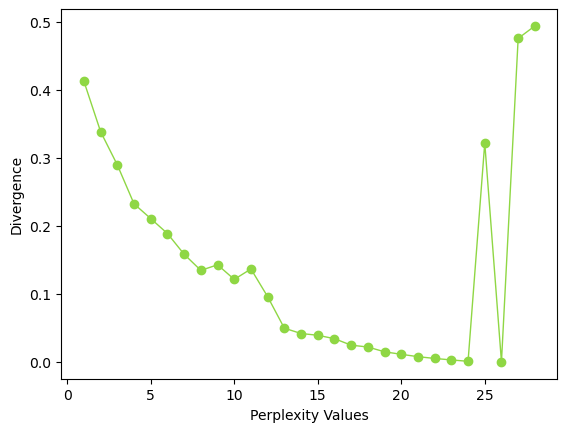

In [45]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [46]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
img_tsne = TSNE(n_components=2, verbose=1, perplexity=24, n_iter=5000)
img_tsne_results = img_tsne.fit_transform(img_all)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.002s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 13.444949
[t-SNE] KL divergence after 250 iterations with early exaggeration: 48.058128
[t-SNE] KL divergence after 750 iterations: 0.271011
t-SNE done! Time elapsed: 0.11429500579833984 seconds


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [47]:
# Create DataFrame of tSNE results
df_img_tsne_class = pd.DataFrame()
df_img_tsne_class["tsne_one"] = img_tsne_results[:,0]
df_img_tsne_class["tsne_two"] = img_tsne_results[:,1]
df_img_tsne_class["SURGICAL"] = img_class

df_img_tsne_class

,tsne_one,tsne_two,SURGICAL
0,-12.520510,-5.287059,M-S
1,14.909671,13.134918,M-S
2,-7.748357,-9.151369,M-S
3,9.704445,13.898416,M-S
4,-0.447821,3.766476,M-S
5,-1.082900,-6.879622,M-S
6,3.852759,0.250199,M-S
7,-0.768601,-1.137518,M-S
8,9.349475,-2.179437,B-S
9,3.837957,14.618138,M-S


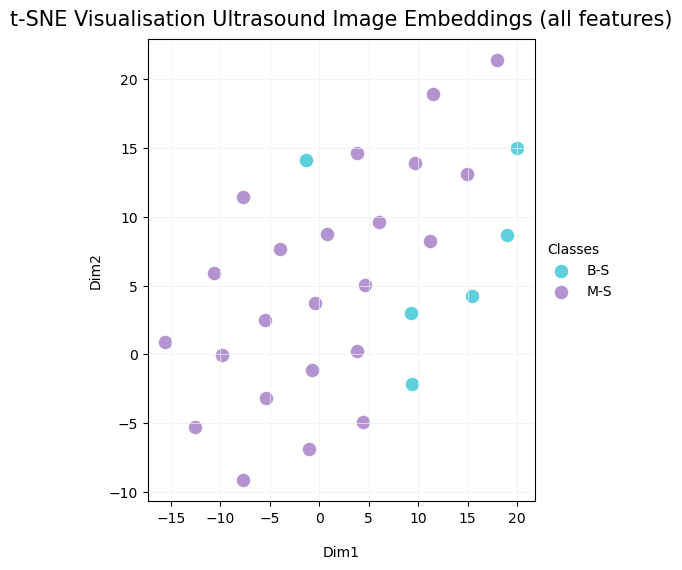

In [48]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_img_tsne_class["SURGICAL"] == target
    xdata = df_img_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_img_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation Ultrasound Image Embeddings (all features)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Spearman Rho Correlation Coefficient

In [49]:
thresholds = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def spearman_thresh_function(features, target, thresholds):
    threshold_list = []
    num_features = []

    column_names = features.columns.tolist()

    for threshold in thresholds:
        threshold_list.append(threshold)
        count = 0
        for column in column_names:
            corr, pval = spearmanr(features[column], target)
            if (corr != 0.9):
                if (corr >= threshold and corr <= threshold+1):
                    count += 1
            else:
                if (corr >= threshold):
                    count += 1
        num_features.append(count)

    return threshold_list, num_features

In [50]:
# Seperating out the features
image_features = image_train_test_df.drop(["image_name", "SURGICAL"], axis=1)

# Seperating out the target
image_class_cat = pd.Categorical(image_train_test_df["SURGICAL"].astype("category")).codes

In [51]:
image_thresholds, image_threshold_counts = spearman_thresh_function(image_features, image_class_cat, thresholds)

In [52]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, image_thresholds),
        "Feature Count": image_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,66
1,0.1,62
2,0.2,58
3,0.3,41
4,0.4,15
5,0.5,1
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


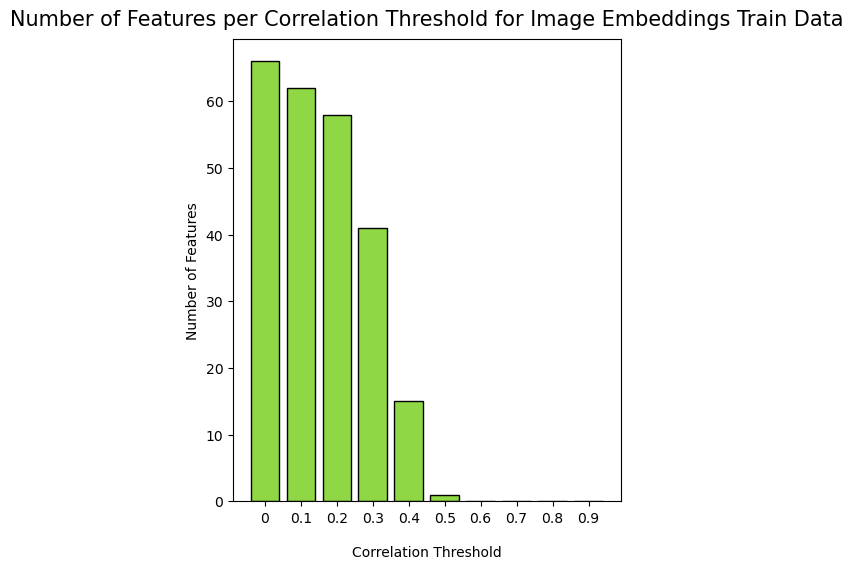

In [53]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold for Image Embeddings Train Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [54]:
def spearman_df_function(features, target, threshold):
    feature_names = []
    feature_correlations = []
    
    column_names = features.columns.tolist()

    for column in column_names:
        corr, pval = spearmanr(features[column], target)
        if (corr >= threshold):
            feature_names.append(column)
            feature_correlations.append(corr)

    return feature_names, feature_correlations

In [55]:
image_feature_names, image_feature_correlations = spearman_df_function(image_features, image_class_cat, 0.40)

In [56]:
spearman_df = pd.DataFrame(
    {
        "Features": image_feature_names,
        "Correlations": image_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,0,0.468025
1,13,0.498549
2,21,0.417153
3,22,0.437502
4,31,0.437502
5,39,0.478200
6,48,0.417153
7,55,0.427327
8,79,0.406978
9,82,0.468025


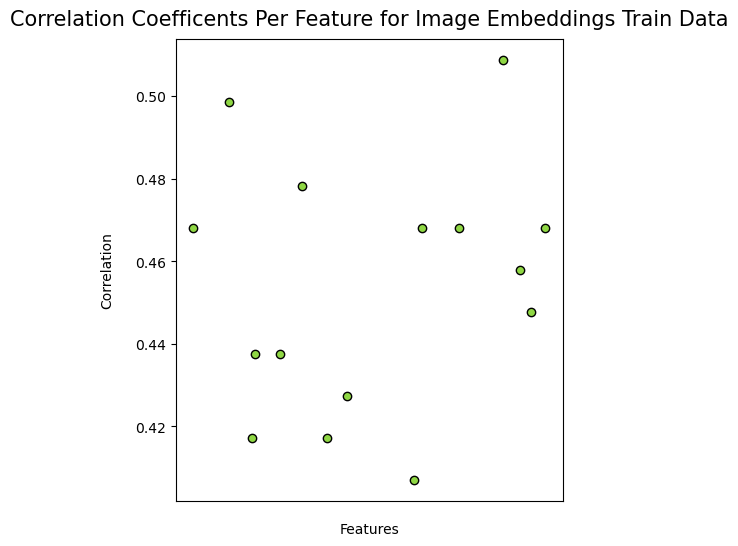

In [57]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature for Image Embeddings Train Data", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [58]:
# Store spearman features
spearman_image = spearman_df["Features"].to_list()

In [59]:
# Seperating out the features
img_spear = image_train_test_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top spear
img_spear = img_spear.loc[:, img_spear.columns.isin(spearman_image)]
# Seperating out the target
img_class = image_train_test_df[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [60]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(img_spear)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

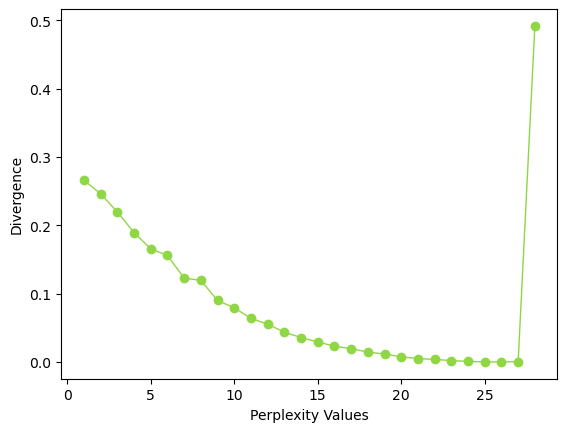

In [61]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [62]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
img_tsne = TSNE(n_components=2, verbose=1, perplexity=27, n_iter=5000)
img_tsne_results = img_tsne.fit_transform(img_spear)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.001s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 8.814506
[t-SNE] KL divergence after 250 iterations with early exaggeration: 40.163479
[t-SNE] KL divergence after 1450 iterations: 0.000458
t-SNE done! Time elapsed: 0.22230172157287598 seconds


In [63]:
# Create DataFrame of tSNE results
df_img_tsne_class = pd.DataFrame()
df_img_tsne_class["tsne_one"] = img_tsne_results[:,0]
df_img_tsne_class["tsne_two"] = img_tsne_results[:,1]
df_img_tsne_class["SURGICAL"] = img_class

df_img_tsne_class

,tsne_one,tsne_two,SURGICAL
0,-4.911902,1.464050,M-S
1,-4.895151,0.368576,M-S
2,-4.922365,1.494352,M-S
3,-4.912588,0.543379,M-S
4,-4.805980,1.053209,M-S
5,-4.842050,1.196735,M-S
6,-5.084158,1.050536,M-S
7,-5.037816,1.117381,M-S
8,-4.944409,0.761442,B-S
9,-5.049781,0.821410,M-S


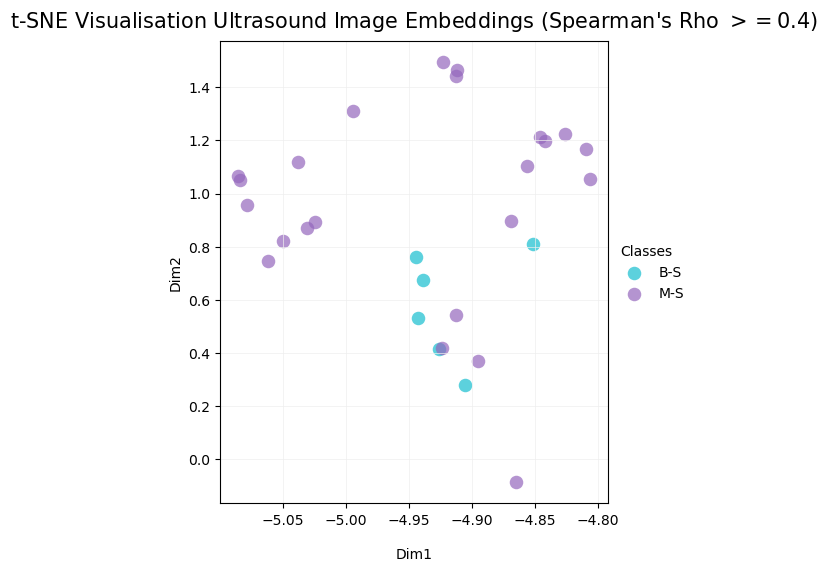

In [64]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_img_tsne_class["SURGICAL"] == target
    xdata = df_img_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_img_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation Ultrasound Image Embeddings (Spearman's Rho $ >= 0.4$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

### RNA - Principal Component Analysis (2 Components)

In [65]:
rna_train_test_df = pd.concat([rna_train_df, rna_test_df], ignore_index=True)

In [66]:
rna_train_test_df

,image_name,SURGICAL,0,1,2,3,4,5,6,7,...,118,119,120,121,122,123,124,125,126,127
0,24903_0011.nii.gz,M-S,0.304861,0.436218,0.064396,0.129112,0.154661,-0.544508,0.162488,0.965045,...,-0.818838,-0.574058,-0.274951,0.504377,0.729716,-0.240964,-0.297036,0.546716,0.341730,-0.169131
1,14984_0039.nii.gz,M-S,-0.951101,-1.074152,-0.956899,-0.767024,-1.444273,0.762624,-1.116339,0.272712,...,0.017743,1.073963,0.978063,-1.474552,-1.061243,1.041335,0.961776,-0.541563,-1.354614,1.031505
2,14056_3.nii.gz,M-S,-1.635989,-1.462788,-1.556259,-1.620565,-0.921801,2.712524,-1.553909,-1.713926,...,0.129878,-1.651163,1.187834,-1.547241,-1.456708,1.672042,1.500290,-1.695276,-1.611549,1.121053
3,25962_0006.nii.gz,M-S,1.401163,1.555053,1.392733,1.195136,1.347291,-1.156185,1.526976,1.352748,...,-0.848828,1.984759,-1.212096,1.148925,1.404802,-1.443003,-1.610782,1.253389,1.335076,-1.320378
4,26604_0007.nii.gz,M-S,0.589761,0.453263,0.813237,0.627795,0.936244,-0.202328,0.668676,0.337964,...,-1.451478,-0.017765,-0.713423,0.557491,0.523457,-0.713380,-0.509064,0.286940,0.715725,-0.353143
5,26428_0020.nii.gz,M-S,-1.221494,-1.144590,-1.050444,-1.377577,-1.909562,1.448675,-1.412095,-1.092005,...,1.444034,-0.865468,1.563099,-1.560754,-1.524432,1.302059,0.835535,-1.216830,-1.132384,1.339122
6,187867.nii.gz,M-S,0.626427,0.596827,0.645183,0.673602,0.797488,-0.779459,0.747957,0.004331,...,-0.231131,0.925805,-0.617890,0.799909,0.558893,-0.680508,-0.642444,0.602965,0.857254,-0.779952
7,14654_3.nii.gz,M-S,-1.145689,-0.546598,-1.419401,-1.149243,-0.828405,0.709405,-1.156941,-1.557694,...,1.419620,-1.531419,0.770647,-0.976314,-1.232602,0.886761,1.344901,-0.878808,-1.149635,1.098795
8,16439_0004.nii.gz,B-S,-0.170944,0.068178,0.217362,-0.332702,0.180586,-0.811594,0.328054,0.485278,...,-0.113412,0.575113,-0.090565,0.278592,0.392860,-0.107018,0.055211,0.176423,0.035744,0.036075
9,14024_2.nii.gz,M-S,-0.672325,-0.617358,-0.941397,-0.946124,-0.527032,0.341233,-0.822879,0.109970,...,0.678812,-1.642437,0.834030,-0.505580,-0.943887,1.135899,0.620300,-0.545011,-1.036950,1.111368


In [68]:
# Seperating out the features
rna_all = rna_train_test_df.drop(["image_name", "SURGICAL"], axis=1)
# Seperating out the target
rna_class = rna_train_test_df[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [69]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(rna_all)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

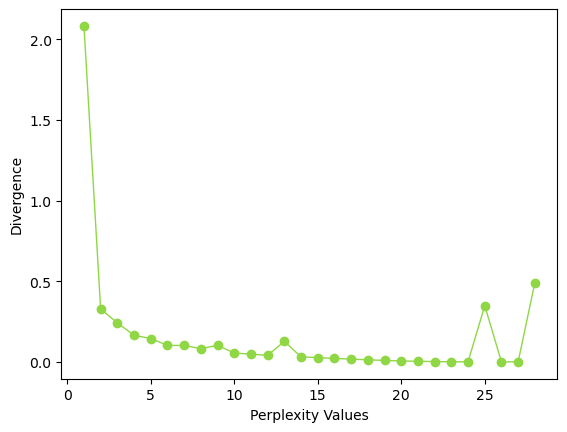

In [70]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [71]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
rna_tsne = TSNE(n_components=2, verbose=1, perplexity=20, n_iter=5000)
rna_tsne_results = rna_tsne.fit_transform(rna_all)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.000s...
[t-SNE] Computed neighbors for 29 samples in 0.014s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 12.106581
[t-SNE] KL divergence after 250 iterations with early exaggeration: 44.876316
[t-SNE] KL divergence after 1100 iterations: 0.006103
t-SNE done! Time elapsed: 0.18662595748901367 seconds


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [72]:
# Create DataFrame of tSNE results
df_rna_tsne_class = pd.DataFrame()
df_rna_tsne_class["tsne_one"] = rna_tsne_results[:,0]
df_rna_tsne_class["tsne_two"] = rna_tsne_results[:,1]
df_rna_tsne_class["SURGICAL"] = rna_class

df_rna_tsne_class

,tsne_one,tsne_two,SURGICAL
0,2.572116,-0.205811,M-S
1,2.507709,1.954286,M-S
2,2.553338,2.440580,M-S
3,2.538183,-1.275663,M-S
4,2.594732,-0.464414,M-S
5,2.612853,2.095709,M-S
6,2.349591,-0.480688,M-S
7,2.647629,1.832038,M-S
8,2.712191,0.286993,B-S
9,2.561593,1.633440,M-S


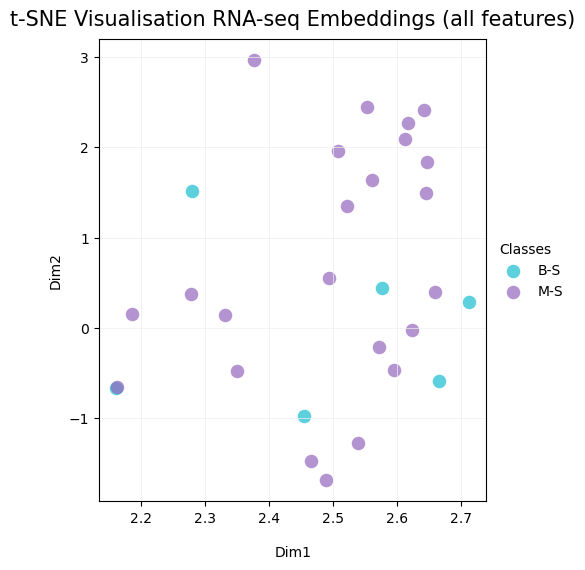

In [73]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_tsne_class["SURGICAL"] == target
    xdata = df_rna_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_rna_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation RNA-seq Embeddings (all features)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()

#### Spearman Rho Correlation Coefficient

In [74]:
# Seperating out the features
rna_features = rna_train_test_df.drop(["image_name", "SURGICAL"], axis=1)

# Seperating out the target
rna_class_cat = pd.Categorical(rna_train_test_df["SURGICAL"].astype("category")).codes

In [75]:
rna_thresholds, rna_threshold_counts = spearman_thresh_function(rna_features, rna_class_cat, thresholds)

In [76]:
threshold_df = pd.DataFrame(
    {
        "Threshold": map(str, rna_thresholds),
        "Feature Count": rna_threshold_counts
    }
)

threshold_df

,Threshold,Feature Count
0,0,61
1,0.1,56
2,0.2,35
3,0.3,3
4,0.4,1
5,0.5,0
6,0.6,0
7,0.7,0
8,0.8,0
9,0.9,0


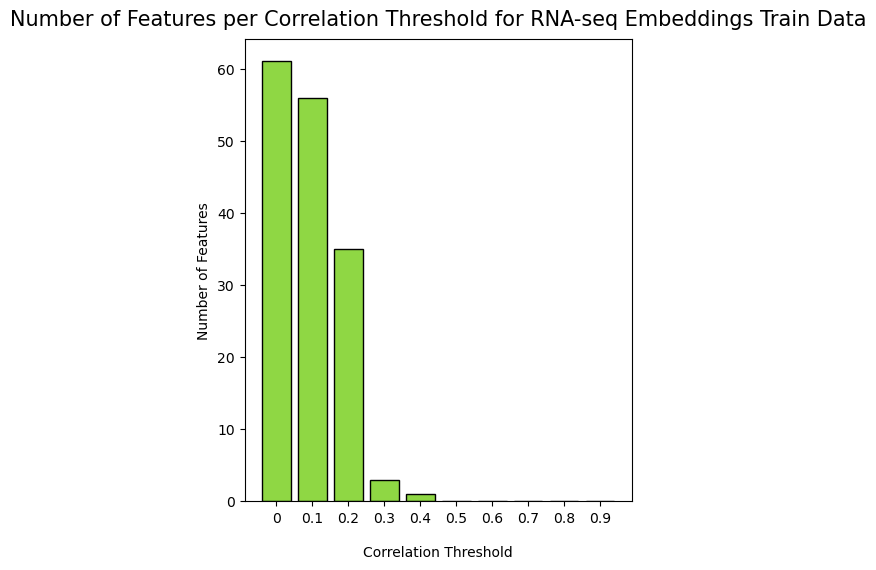

In [77]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.bar(threshold_df["Threshold"], threshold_df["Feature Count"], color="#8FD744FF", edgecolor="black")
ax.set_title("Number of Features per Correlation Threshold for RNA-seq Embeddings Train Data", fontsize = 15, pad=10)
ax.set_xlabel("Correlation Threshold", fontsize=10, labelpad=15)
ax.set_ylabel("Number of Features", fontsize=10)
plt.show()

In [82]:
rna_feature_names, rna_feature_correlations = spearman_df_function(rna_features, rna_class_cat, 0.25)

In [83]:
spearman_df = pd.DataFrame(
    {
        "Features": rna_feature_names,
        "Correlations": rna_feature_correlations
    }
)

spearman_df

,Features,Correlations
0,5,0.417153
1,14,0.274710
2,20,0.254362
3,56,0.264536
4,76,0.305234
5,89,0.254362
6,101,0.315408
7,107,0.254362
8,108,0.274710
9,116,0.264536


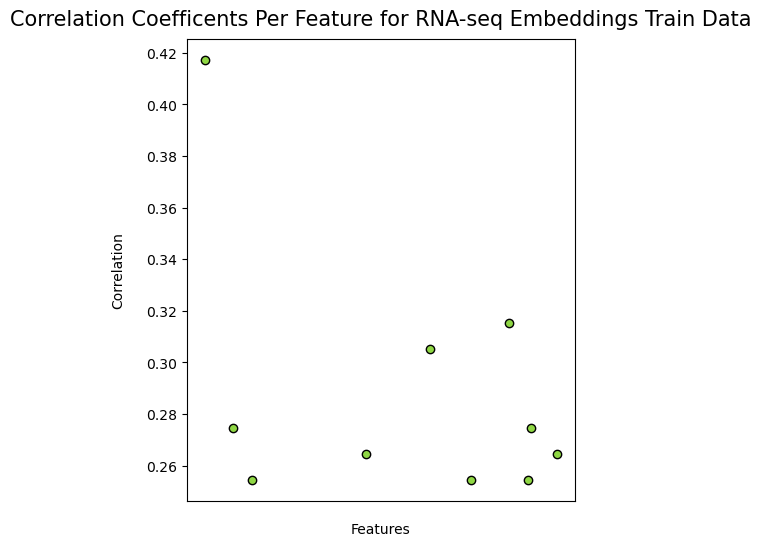

In [84]:
fig,ax = plt.subplots(figsize=(5, 6)) 
ax.scatter(spearman_df["Features"], spearman_df["Correlations"], color="#8FD744FF", edgecolors="black")
ax.set_title("Correlation Coefficents Per Feature for RNA-seq Embeddings Train Data", fontsize = 15, pad=10)
ax.set_xlabel("Features", fontsize=10, labelpad=15)
ax.set_ylabel("Correlation", fontsize=10, labelpad=15)

plt.tick_params(bottom=False, labelbottom=False)
plt.show()

In [85]:
# Store spearman features
spearman_rna = spearman_df["Features"].to_list()

In [86]:
# Seperating out the features
rna_spear = rna_train_test_df.drop(["image_name", "SURGICAL"], axis=1)
# Only keep the top features
rna_spear = rna_spear.loc[:, rna_spear.columns.isin(spearman_rna)]
# Seperating out the target
rna_class = rna_train_test_df[["SURGICAL"]]

Determine perplexity to use for t-SNE:

In [87]:
perplexities = np.arange(1, 29)
KL_divergences = []

for i in perplexities:
    # Create tSNE embedding with 2 dimensions
    tsne = TSNE(n_components=2, verbose=0, perplexity=i, n_iter=5000)
    tsne_results = tsne.fit_transform(rna_spear)
    tsne_div = tsne.kl_divergence_
    # Add divergence to array
    KL_divergences.append(tsne_div)

/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and w

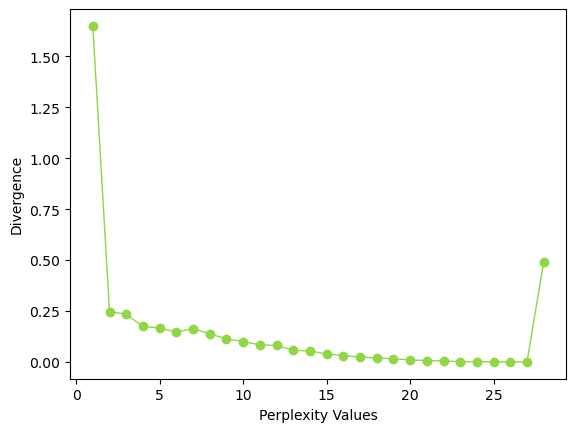

In [88]:
plt.plot(perplexities, KL_divergences, marker="o", color="#8FD744FF", linewidth=1)
plt.xlabel("Perplexity Values")
plt.ylabel("Divergence")

plt.show()

In [89]:
# Create tSNE embedding with 2 dimensions
time_start = time.time()
rna_tsne = TSNE(n_components=2, verbose=1, perplexity=27, n_iter=5000)
rna_tsne_results = rna_tsne.fit_transform(rna_spear)

print('t-SNE done! Time elapsed: {} seconds'.format(time.time()-time_start))

[t-SNE] Computing 28 nearest neighbors...
[t-SNE] Indexed 29 samples in 0.001s...
[t-SNE] Computed neighbors for 29 samples in 0.015s...
[t-SNE] Computed conditional probabilities for sample 29 / 29
[t-SNE] Mean sigma: 8.339157
[t-SNE] KL divergence after 250 iterations with early exaggeration: 37.961178
[t-SNE] KL divergence after 1000 iterations: 0.000210
t-SNE done! Time elapsed: 0.15679264068603516 seconds


/home/kryan24/miniconda3/envs/ovcan/lib/python3.12/site-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


In [90]:
# Create DataFrame of tSNE results
df_rna_tsne_class = pd.DataFrame()
df_rna_tsne_class["tsne_one"] = rna_tsne_results[:,0]
df_rna_tsne_class["tsne_two"] = rna_tsne_results[:,1]
df_rna_tsne_class["SURGICAL"] = rna_class

df_rna_tsne_class

,tsne_one,tsne_two,SURGICAL
0,2.623320,3.178406,M-S
1,2.526218,3.752647,M-S
2,2.567528,4.007706,M-S
3,2.711348,2.930776,M-S
4,2.465744,3.080003,M-S
5,2.532985,3.866978,M-S
6,2.656620,3.134506,M-S
7,2.575654,3.795978,M-S
8,2.442318,3.221290,B-S
9,2.614412,3.720206,M-S


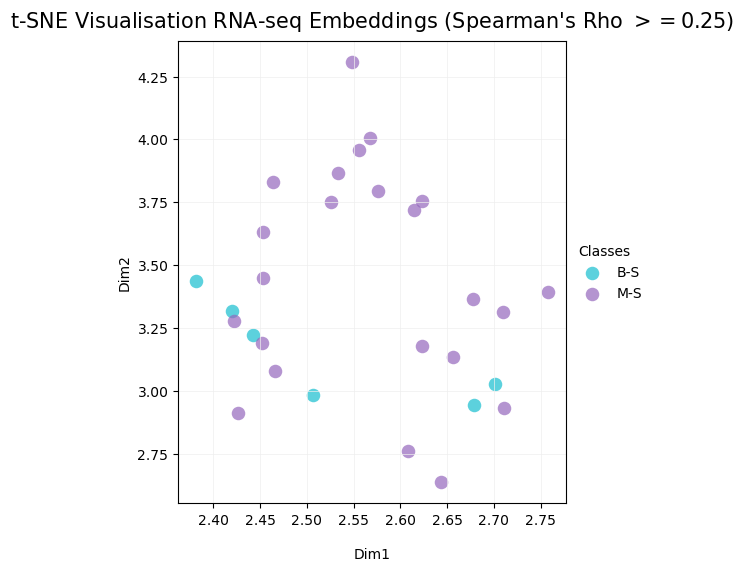

In [91]:
fig, ax = plt.subplots(figsize=(5, 6))
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.right'] = True
plt.rcParams['axes.spines.top'] = True
plt.rcParams['axes.spines.bottom'] = True

targets = ("B-S", "M-S")
colours = ("#17BECF", "#9467BD")

for target, colour in zip(targets, colours):

    # Sort data by class
    indicesToKeep = df_rna_tsne_class["SURGICAL"] == target
    xdata = df_rna_tsne_class.loc[indicesToKeep, "tsne_one"]
    ydata = df_rna_tsne_class.loc[indicesToKeep, "tsne_two"]

    ax.scatter(xdata, ydata,
               label=target, # use labels provided above
               c=colour, # use colors provided above
               lw=0, #remove the outer line of each point
               alpha=0.7, # increase transparency of points
               s=95) # increase the size of points
    
 # Add labels showing percentage of the variance explained
ax.set_title("t-SNE Visualisation RNA-seq Embeddings (Spearman's Rho $ >= 0.25$)", fontsize = 15, pad=10)
ax.set_xlabel('Dim1', fontsize=10, labelpad=15)
ax.set_ylabel('Dim2', fontsize=10)
ax.grid(which="major", color="#EEEEEE", linewidth=0.5)

plt.legend(bbox_to_anchor=(1, 0.5), loc="center left", frameon=False, title="Classes", alignment="left")
plt.show()